In [3]:
import requests
import pandas as pd
import numpy as np

url = "http://localhost/Chronology/fetch_data.php"
res = requests.get(url)
data = res.json()

df = pd.DataFrame(data)

print(df.columns)
print(df.head())

Index(['id', 'crime_id', 'date', 'day', 'month', 'year', 'start_time',
       'end_time', 'location', 'crime_type', 'crime_count'],
      dtype='object')
    id crime_id        date        day     month  year start_time  end_time  \
0  405     C267  2026-05-05    Tuesday       May  2026   12:39:00  15:39:00   
1  404     C278  2026-05-07   Thursday       May  2026   20:58:00  19:02:00   
2  403     C267  2026-04-29  Wednesday       Apr  2026   12:17:00  14:17:00   
3  402     C256  2026-05-07   Thursday       May  2026   18:01:00  19:06:00   
4  396     C250  2025-11-06   Thursday  November  2025   05:00:00  07:00:00   

   location crime_type crime_count  
0     murud   accident           2  
1     mahad     murder           8  
2     mahad   accident           4  
3    alibag      theft           8  
4  Revdanda    Robbery           3  


In [12]:
import numpy as np

df['location_code'] = df['location'].astype('category').cat.codes

df['start_time'] = df['start_time'].astype(str)
df['hour'] = df['start_time'].str.split(":").str[0]
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')

df = df.dropna(subset=['hour', 'location_code'])
df['hour'] = df['hour'].astype(int)

X = df[['location_code', 'hour']].values

X = X + np.random.normal(0, 2, X.shape)

y = []

for h in df['hour']:

    if h < 6:
        p = 0.65
    elif h < 12:
        p = 0.40
    elif h < 18:
        p = 0.50
    else:
        p = 0.75

    y.append(np.random.choice([0, 1], p=[1-p, p]))

y = np.array(y)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 280
Testing samples: 120


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=120),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}


===== OVERALL CRIME ANALYSIS (LOCATION + TIME) =====

Logistic Regression
Accuracy  : 58.33%
Precision : 61.84%
Recall    : 69.12%
F1 Score  : 65.28%

Confusion Matrix:
[[23 29]
 [21 47]]
TN:23, FP:29, FN:21, TP:47


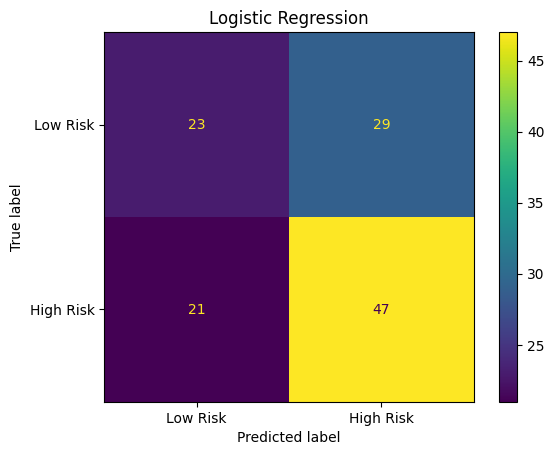

Decision Tree
Accuracy  : 53.33%
Precision : 58.11%
Recall    : 63.24%
F1 Score  : 60.56%

Confusion Matrix:
[[21 31]
 [25 43]]
TN:21, FP:31, FN:25, TP:43


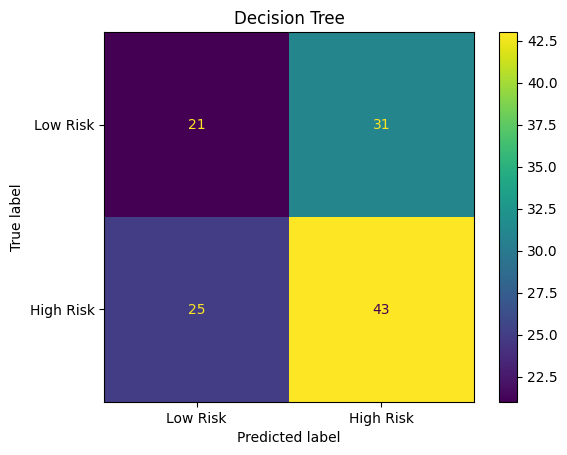

Random Forest
Accuracy  : 52.50%
Precision : 57.53%
Recall    : 61.76%
F1 Score  : 59.57%

Confusion Matrix:
[[21 31]
 [26 42]]
TN:21, FP:31, FN:26, TP:42


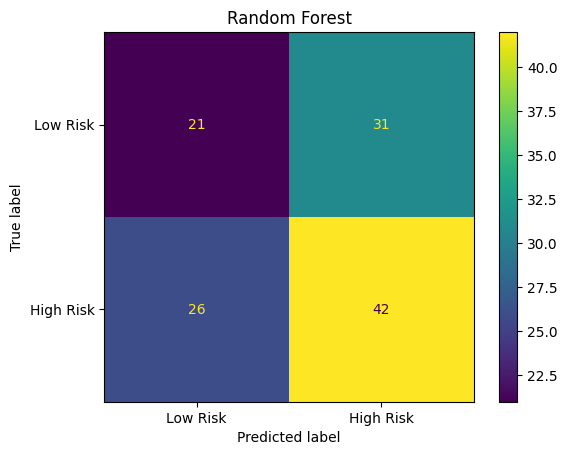

KNN
Accuracy  : 54.17%
Precision : 59.42%
Recall    : 60.29%
F1 Score  : 59.85%

Confusion Matrix:
[[24 28]
 [27 41]]
TN:24, FP:28, FN:27, TP:41


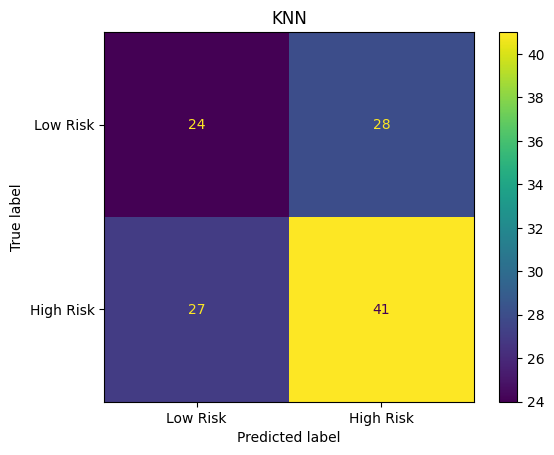

SVM
Accuracy  : 53.33%
Precision : 56.38%
Recall    : 77.94%
F1 Score  : 65.43%

Confusion Matrix:
[[11 41]
 [15 53]]
TN:11, FP:41, FN:15, TP:53


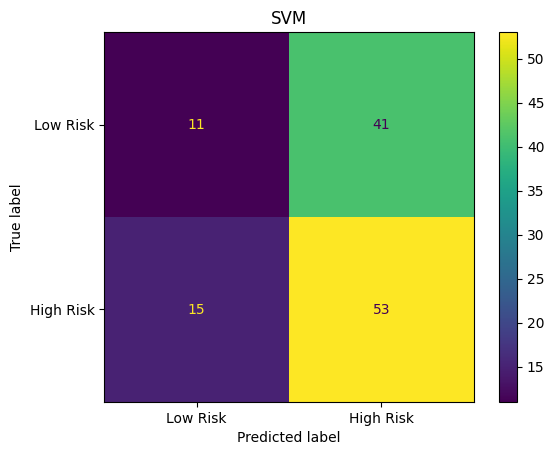

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

results = []

print("\n===== OVERALL CRIME ANALYSIS (LOCATION + TIME) =====\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred) * 100
    prec = precision_score(y_test, pred, zero_division=0) * 100
    rec = recall_score(y_test, pred, zero_division=0) * 100
    f1 = f1_score(y_test, pred, zero_division=0) * 100

    results.append([name, acc, prec, rec, f1])

    print("==============================")
    print(name)
    print("==============================")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1 Score  : {f1:.2f}%")

  
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    print("\nConfusion Matrix:")
    print(cm)
    print(f"TN:{tn}, FP:{fp}, FN:{fn}, TP:{tp}")


    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low Risk", "High Risk"]
    ).plot()

    plt.title(name)
    plt.show()

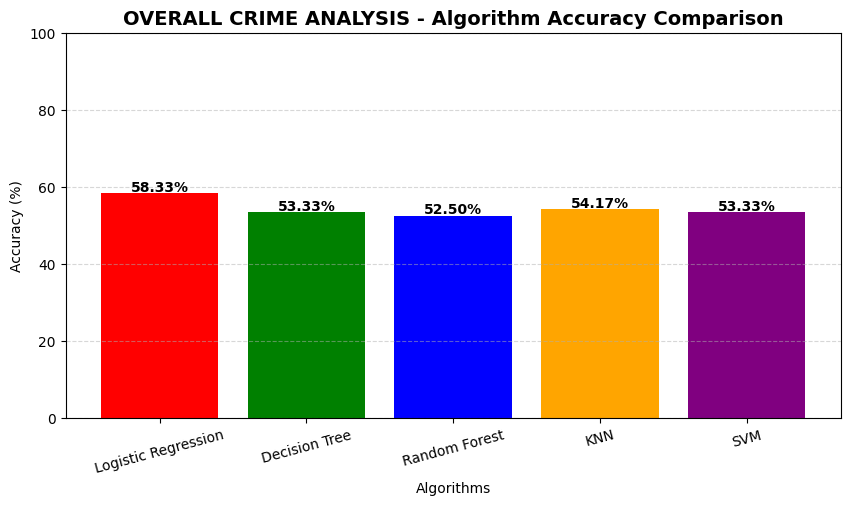

In [9]:
import matplotlib.pyplot as plt

algorithms = [r[0] for r in results]
accuracies = [r[1] for r in results]

colors = ['red', 'green', 'blue', 'orange', 'purple']

plt.figure(figsize=(10,5))

bars = plt.bar(
    algorithms,
    accuracies,
    color=colors
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f"{yval:.2f}%",
        ha='center',
        fontweight='bold'
    )

plt.title("OVERALL CRIME ANALYSIS - Algorithm Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [11]:
ranking = sorted(results, key=lambda x: x[1], reverse=True)

print("\n====================================")
print("FINAL OVERALL MODEL RANKING")
print("====================================\n")

print(f"{'Rank':<5}{'Algorithm':<25}{'Accuracy (%)':<15}")
print("-"*50)

for i, r in enumerate(ranking, 1):
    print(f"{i:<5}{r[0]:<25}{r[1]:<15.2f}")

print("\n====================================")
print("BEST PERFORMING ALGORITHM")
print(f"{ranking[0][0]} → {ranking[0][1]:.2f}% Accuracy")


FINAL OVERALL MODEL RANKING

Rank Algorithm                Accuracy (%)   
--------------------------------------------------
1    Logistic Regression      58.33          
2    KNN                      54.17          
3    Decision Tree            53.33          
4    SVM                      53.33          
5    Random Forest            52.50          

BEST PERFORMING ALGORITHM
Logistic Regression → 58.33% Accuracy
